In [63]:
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [64]:
data = pd.read_csv(r"C:\Users\acer\Desktop\PROJECT\satellite\New\train(1)(train(1)).csv")

In [65]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [66]:
image_data = data[["id", "lat", "long"]]

In [67]:
image_data.head()

,id,lat,long
0,9117000170,47.4362,-122.187
1,6700390210,47.4034,-122.187
2,7212660540,47.2704,-122.313
3,8562780200,47.5321,-122.073
4,7760400350,47.3715,-122.074


In [68]:
y_price = data["price"]

In [69]:
y_price.head()

0    268643
1    245000
2    200000
3    352499
4    232000
Name: price, dtype: int64

In [70]:
data= data[["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","grade","sqft_above","sqft_basement","yr_built","yr_renovated","lat","long","sqft_living15","sqft_lot15"]]

In [71]:
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,4,2.25,1810,9240,2.0,0,0,7,1810,0,1961,0,47.4362,-122.187,1660,9240
1,3,2.50,1600,2788,2.0,0,0,7,1600,0,1992,0,47.4034,-122.187,1720,3605
2,4,2.50,1720,8638,2.0,0,0,8,1720,0,1994,0,47.2704,-122.313,1870,7455
3,2,2.25,1240,705,2.0,0,0,7,1150,90,2009,0,47.5321,-122.073,1240,750
4,3,2.00,1280,13356,1.0,0,0,7,1280,0,1994,0,47.3715,-122.074,1590,8071


In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       16209 non-null  int64  
 1   bathrooms      16209 non-null  float64
 2   sqft_living    16209 non-null  int64  
 3   sqft_lot       16209 non-null  int64  
 4   floors         16209 non-null  float64
 5   waterfront     16209 non-null  int64  
 6   view           16209 non-null  int64  
 7   grade          16209 non-null  int64  
 8   sqft_above     16209 non-null  int64  
 9   sqft_basement  16209 non-null  int64  
 10  yr_built       16209 non-null  int64  
 11  yr_renovated   16209 non-null  int64  
 12  lat            16209 non-null  float64
 13  long           16209 non-null  float64
 14  sqft_living15  16209 non-null  int64  
 15  sqft_lot15     16209 non-null  int64  
dtypes: float64(4), int64(12)
memory usage: 2.0 MB


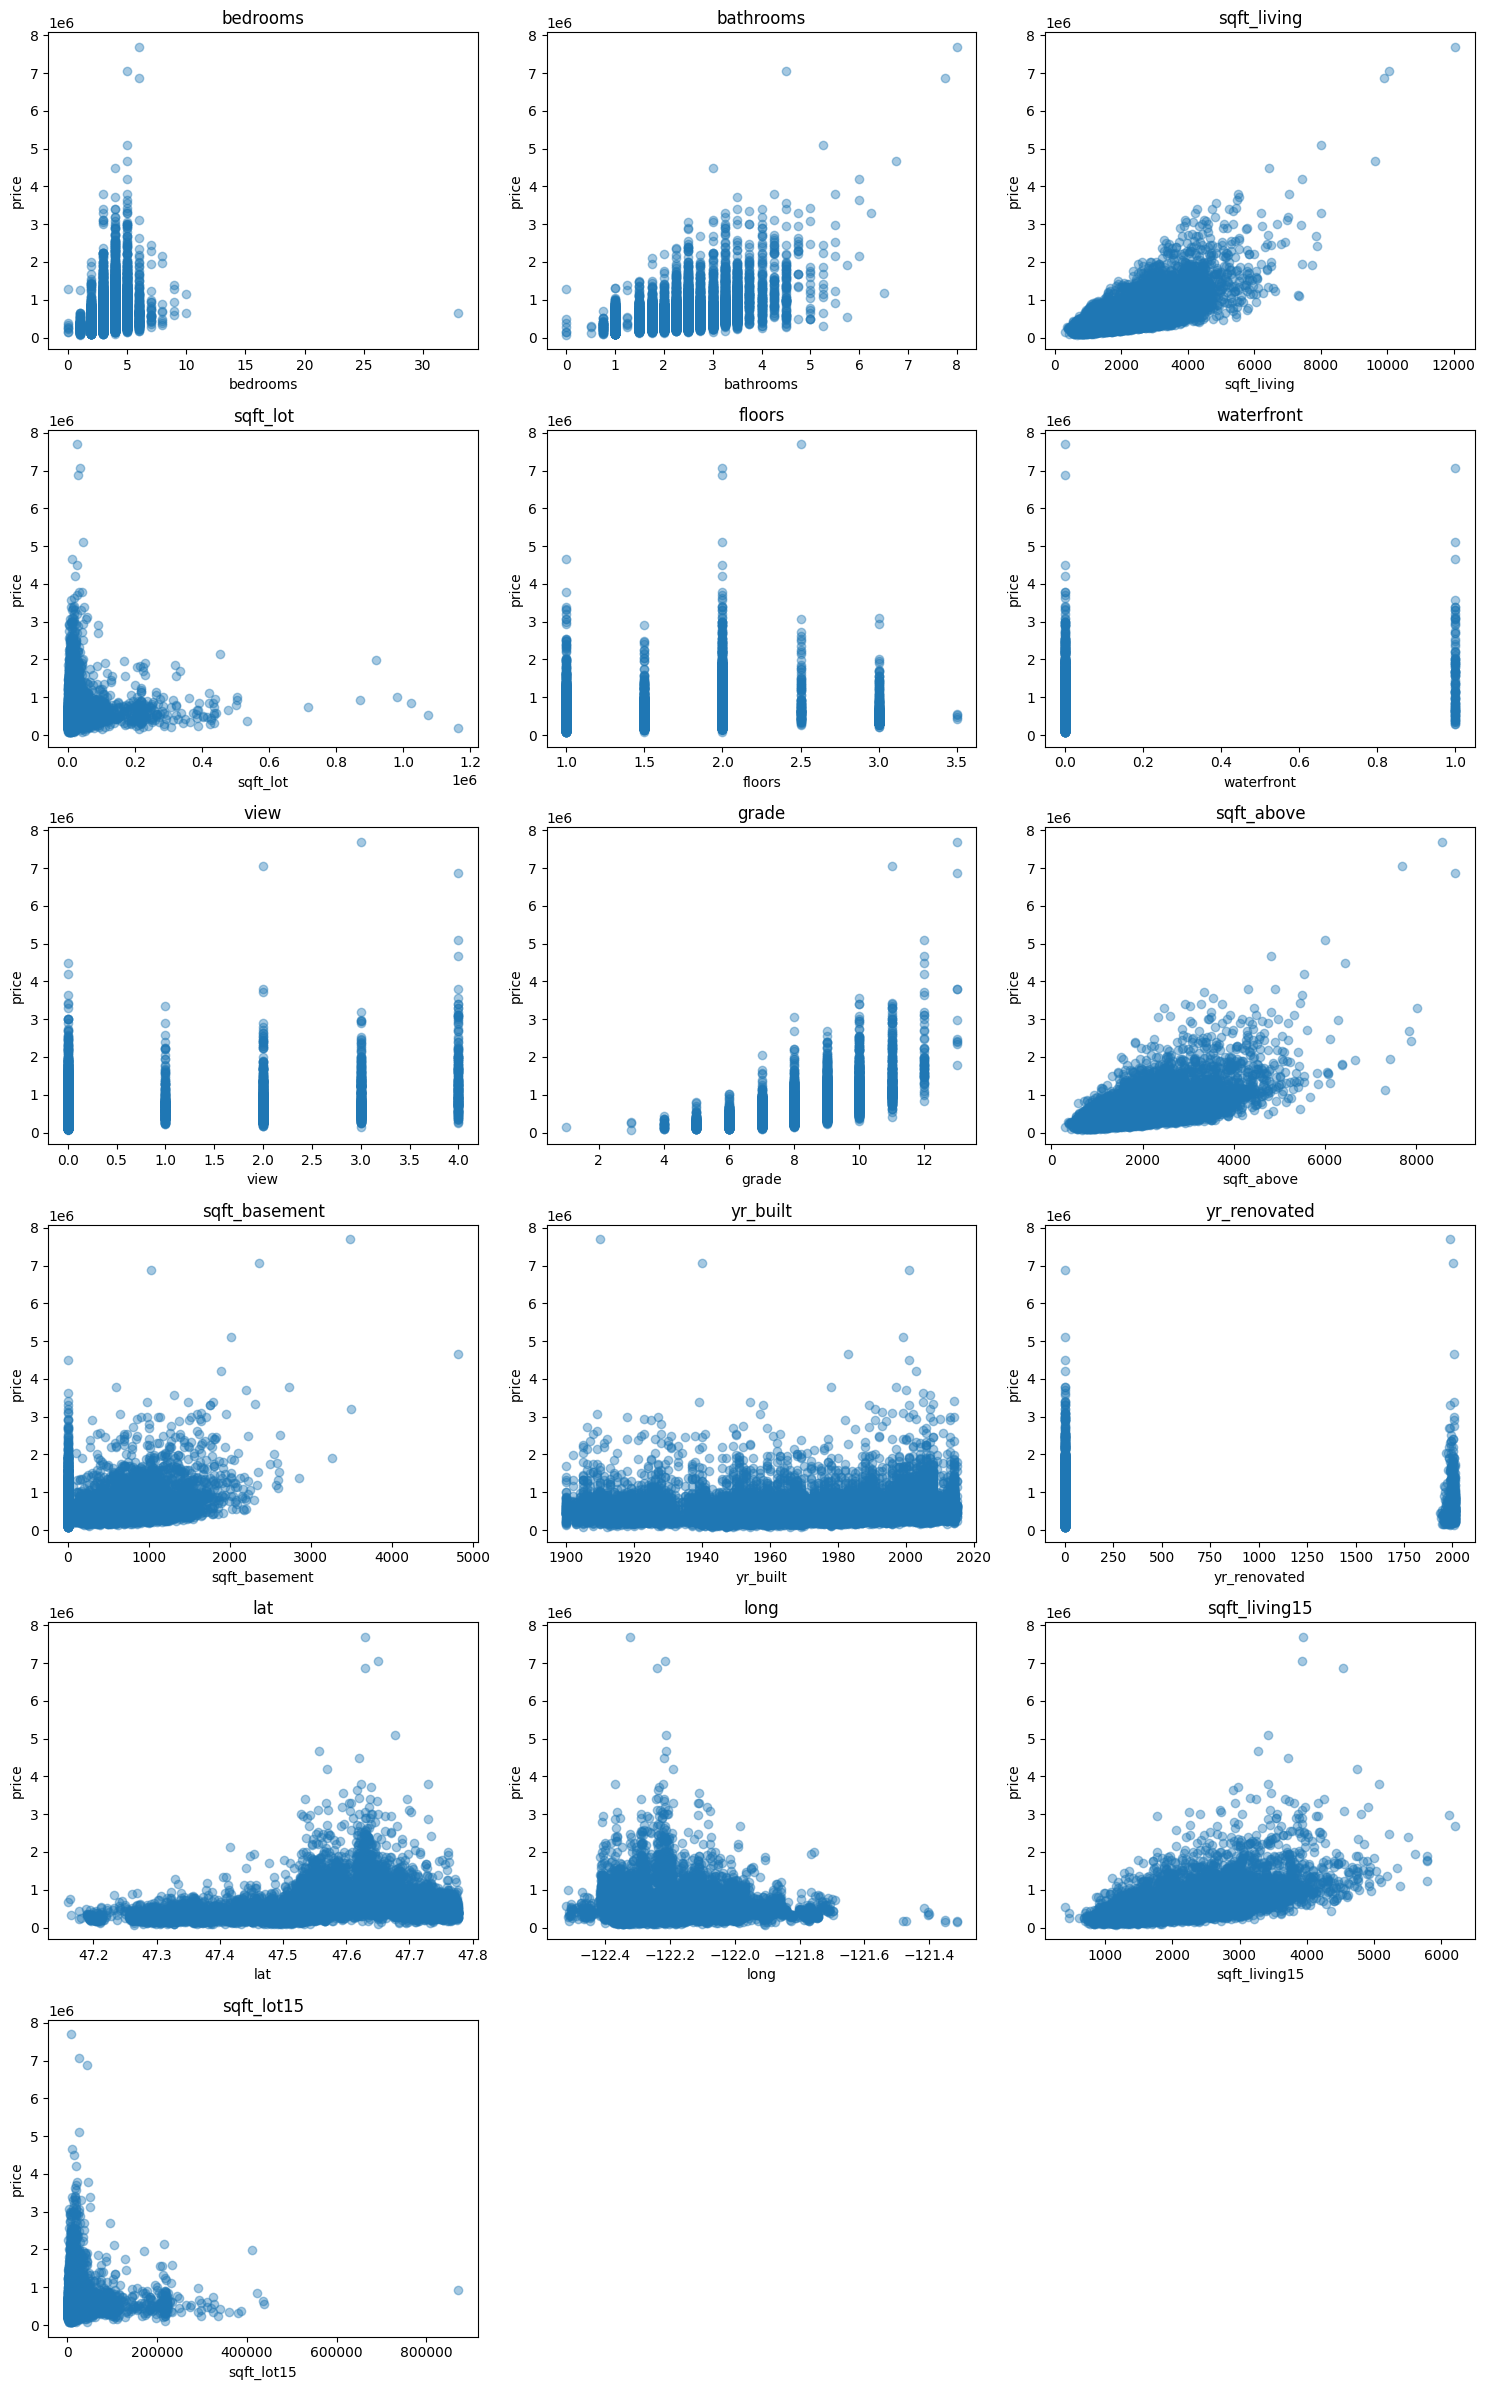

In [73]:
import numpy as np

cols = 3
rows = int(np.ceil(len(data.columns) / cols))

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(data.columns):
    plt.subplot(rows, cols, i + 1)
    plt.scatter(data[col], y_price, alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("price")
    plt.title(col)

plt.tight_layout()
plt.show()


In [74]:
!pip install sentinelhub rasterio


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
import os
import pandas as pd
from sentinelhub import (
    SHConfig, BBox, CRS,
    SentinelHubRequest, DataCollection,
    bbox_to_dimensions
)
import rasterio

In [76]:
config = SHConfig()
config.sh_client_id = "ae54560b-79f0-4405-83f1-f61bdc5019cd"
config.sh_client_secret = "kF4DcglQC3Ao0jJHx4bGhdkf3PbDuFc9"

In [77]:
print(image_data["id"].dtype)


int64


In [78]:
image_data["id"] = image_data["id"].astype("int64")

os.makedirs("images", exist_ok=True)

In [117]:
import os
from sentinelhub import BBox, CRS, MimeType, SentinelHubRequest, DataCollection, bbox_to_dimensions
import rasterio

def fetch_sentinel_image(house_id, lat, lon, config):
    house_id = int(float(house_id))     
    os.makedirs("images", exist_ok=True)

    image_path = f"images/{house_id}.tif"
    
    
    if os.path.exists(image_path):
        return image_path


    bbox = BBox(
       bbox=[lon - 0.005, lat - 0.005, lon + 0.005, lat + 0.005]
,
        crs=CRS.WGS84
    )

    size = bbox_to_dimensions(bbox, resolution=5)


   
    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: ["B04", "B03", "B02"],
            output: { bands: 3 }
        };
    }
    function evaluatePixel(sample) {
        return [sample.B04, sample.B03, sample.B02];
    }
    """

  
    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=("2023-01-01", "2023-12-31"),
                mosaicking_order="mostRecent"
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config
    )

 
    image = request.get_data()[0]

    
    os.makedirs("images", exist_ok=True)
    with rasterio.open(
        image_path,
        "w",
        driver="GTiff",
        height=image.shape[0],
        width=image.shape[1],
        count=3,
        dtype=image.dtype
    ) as dst:
        for i in range(3):
            dst.write(image[:, :, i], i + 1)

  
    return image_path

In [80]:
print(image_data["id"].dtype)


int64


In [118]:
for _, row in image_data.iterrows():
    fetch_sentinel_image(row["id"], row["lat"], row["long"], config=config)

print("✅ Sentinel Hub satellite images processed.")

✅ Sentinel Hub satellite images processed.


c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


(np.float64(-0.5), np.float64(147.5), np.float64(223.5), np.float64(-0.5))

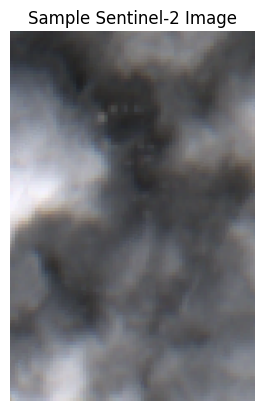

In [82]:
import rasterio
import matplotlib.pyplot as plt

path = "images/9521100585.tif"  

with rasterio.open(path) as src:
    img = src.read()  

rgb = img.transpose(1, 2, 0)
plt.imshow(rgb / rgb.max())
plt.title("Sample Sentinel-2 Image")
plt.axis("off")


In [83]:
data = data.reset_index(drop=True)
data["id"] = data.index.astype("int64")

In [84]:
image_data["id"] = image_data["id"].apply(lambda x: int(float(x)))
image_data["image_path"] = image_data["id"].apply(
    lambda x: f"images/{x}.tif"
)



In [ ]:
import os


def normalize_id(x):
    try:
        return int(float(x))
    except:
        return None



if not os.path.exists("images"):
    raise FileNotFoundError(" 'images/' folder not found")

image_files = [f for f in os.listdir("images") if f.endswith(".tif")]

if len(image_files) == 0:
    raise ValueError(" No .tif images found in 'images/'")


id_to_path = {
    normalize_id(f.replace(".tif", "")): os.path.join("images", f)
    for f in image_files
}


image_data["id_norm"] = image_data["id"].apply(normalize_id)


image_data["image_path"] = image_data["id_norm"].map(id_to_path)


image_data = image_data.dropna(subset=["image_path"]).reset_index(drop=True)


image_data.drop(columns=["id_norm"], inplace=True)


print("✅ Final shape:", image_data.shape)
print(image_data["image_path"].head())

if len(image_data) > 0:
    print("✅ File exists:", os.path.exists(image_data["image_path"].iloc[0]))
else:
    print(" No matching images found")



✅ Final shape: (16209, 4)
0    images\9117000170.tif
1    images\6700390210.tif
2    images\7212660540.tif
3    images\8562780200.tif
4    images\7760400350.tif
Name: image_path, dtype: object
✅ File exists: True


In [86]:

print("Image IDs (from filenames):")
print(sorted(list(id_to_path.keys()))[:10])


print(" DataFrame IDs:")
print(image_data["id"].head(10).tolist())


print("\n📊 Normalized DataFrame IDs:")
print(image_data["id"].apply(lambda x: int(float(x))).head(10).tolist())


Image IDs (from filenames):
[1000102, 1200019, 1200021, 2800031, 3600057, 5200087, 7200080, 7200179, 7400062, 7600057]
 DataFrame IDs:
[9117000170, 6700390210, 7212660540, 8562780200, 7760400350, 464001025, 3432500486, 1126059095, 3876500290, 1865400075]

📊 Normalized DataFrame IDs:
[9117000170, 6700390210, 7212660540, 8562780200, 7760400350, 464001025, 3432500486, 1126059095, 3876500290, 1865400075]


In [87]:
print("Does ANY image ID exist in dataframe IDs?\n")

image_ids = set(id_to_path.keys())
df_ids = set(image_data["id"].apply(lambda x: int(float(x))))

print("Intersection count:", len(image_ids.intersection(df_ids)))


Does ANY image ID exist in dataframe IDs?

Intersection count: 16110


In [88]:
image_data = image_data[
    image_data["id"].apply(lambda x: int(float(x)) in id_to_path)
].copy()

image_data["image_path"] = image_data["id"].apply(
    lambda x: id_to_path[int(float(x))]
)


In [89]:
print(data.shape)
print(image_data.shape)

print(image_data.head())
print(os.path.exists(image_data.iloc[0]["image_path"]))


(16209, 17)
(16209, 4)
           id      lat     long             image_path
0  9117000170  47.4362 -122.187  images\9117000170.tif
1  6700390210  47.4034 -122.187  images\6700390210.tif
2  7212660540  47.2704 -122.313  images\7212660540.tif
3  8562780200  47.5321 -122.073  images\8562780200.tif
4  7760400350  47.3715 -122.074  images\7760400350.tif
True


In [90]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import numpy as np
from torch.utils.data import Dataset



In [91]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, output_dim=512):
        super().__init__()
      
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
      
        self.fc = nn.Linear(128 * 28 * 28, output_dim)  

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = self.pool(x) 

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [92]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = SimpleCNN(output_dim=512).to(device)
cnn_model.eval()  

from torchvision import transforms
from PIL import Image
import numpy as np


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def get_image_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = cnn_model(img_t)
    return emb.squeeze().cpu().numpy() 


In [93]:

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


full_data = data.copy()
full_data["image_path"] = image_data["image_path"].values  

# 2️⃣ Tabular features
tabular_cols = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","grade",
                "sqft_above","sqft_basement","yr_built","yr_renovated","lat","long",
                "sqft_living15","sqft_lot15"]

X_tabular = full_data[tabular_cols].astype(float).values


image_embeddings = np.array([get_image_embedding(p) for p in full_data['image_path']])


X = np.hstack([X_tabular, image_embeddings])
y = y_price.values  



X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

reg = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
reg.fit(X_train, y_train_scaled)
y_pred_scaled = reg.predict(X_val)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()


In [112]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
RMSE = np.sqrt(17759873024)

print("✅ Mean Squared Error (MSE):", mse)
print("✅ R-squared (R²):", r2)
print("✅ RMSE:", RMSE)


✅ Mean Squared Error (MSE): 16844379136.0
✅ R-squared (R²): 0.865769624710083
✅ RMSE: 133266.17359255123


In [95]:
RMSE = np.sqrt(17759873024)
print(RMSE)


133266.17359255123


In [96]:
data2 = pd.read_csv(r"C:\Users\acer\Desktop\PROJECT\satellite\test2(test(1)).csv")

In [97]:
data2.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2591820310,20141006T000000,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
1,7974200820,20140821T000000,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
2,7701450110,20140815T000000,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
3,9522300010,20150331T000000,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
4,9510861140,20140714T000000,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050


In [98]:
image_data2 = data2[["id", "lat", "long"]]

In [99]:
data2= data2[["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","grade","sqft_above","sqft_basement","yr_built","yr_renovated","lat","long","sqft_living15","sqft_lot15"]]

In [100]:
image_data2["id"] = image_data2["id"].astype("int64")

os.makedirs("test", exist_ok=True)

In [115]:
import os
from sentinelhub import BBox, CRS, MimeType, SentinelHubRequest, DataCollection, bbox_to_dimensions
import rasterio

def fetch_sentinel_image2(house_id, lat, lon, config):
    house_id = int(float(house_id))     
    os.makedirs("test", exist_ok=True)

    image_path = f"test/{house_id}.tif"
    
    
    if os.path.exists(image_path):
       
        return image_path


    bbox = BBox(
       bbox=[lon - 0.005, lat - 0.005, lon + 0.005, lat + 0.005]
,
        crs=CRS.WGS84
    )

    size = bbox_to_dimensions(bbox, resolution=5)


   
    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: ["B04", "B03", "B02"],
            output: { bands: 3 }
        };
    }
    function evaluatePixel(sample) {
        return [sample.B04, sample.B03, sample.B02];
    }
    """

  
    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=("2023-01-01", "2023-12-31"),
                mosaicking_order="mostRecent"
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config
    )

 
    image = request.get_data()[0]

    
    os.makedirs("test", exist_ok=True)
    with rasterio.open(
        image_path,
        "w",
        driver="GTiff",
        height=image.shape[0],
        width=image.shape[1],
        count=3,
        dtype=image.dtype
    ) as dst:
        for i in range(3):
            dst.write(image[:, :, i], i + 1)
   
  
    return image_path

In [102]:
image_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5404 entries, 0 to 5403
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      5404 non-null   int64  
 1   lat     5404 non-null   float64
 2   long    5404 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 126.8 KB


In [116]:
for _, row in image_data2.iterrows():
    fetch_sentinel_image2(row["id"], row["lat"], row["long"], config=config)

print("✅ Sentinel Hub satellite images processed.")

✅ Sentinel Hub satellite images processed.


In [104]:
data2 = data2.reset_index(drop=True)
data2["id"] = data2.index.astype("int64")

In [ ]:
if not os.path.exists("test"):
    raise FileNotFoundError(" 'test/' folder not found")

image_files2 = [f for f in os.listdir("test") if f.endswith(".tif")]

if len(image_files2) == 0:
    raise ValueError(" No .tif images found in 'test/'")


id_to_path = {
    normalize_id(f.replace(".tif", "")): os.path.join("test", f)
    for f in image_files2
}


image_data2["id_norm"] = image_data2["id"].apply(normalize_id)


image_data2["image_path"] = image_data2["id_norm"].map(id_to_path)


image_data2 = image_data2.dropna(subset=["image_path"]).reset_index(drop=True)


image_data2.drop(columns=["id_norm"], inplace=True)


print("✅ Final shape:", image_data2.shape)
print(image_data2["image_path"].head())

if len(image_data2) > 0:
    print("✅ File exists:", os.path.exists(image_data2["image_path"].iloc[0]))
else:
    print(" No matching images found")



✅ Final shape: (5404, 4)
0    test\2591820310.tif
1    test\7974200820.tif
2    test\7701450110.tif
3    test\9522300010.tif
4    test\9510861140.tif
Name: image_path, dtype: object
✅ File exists: True


In [106]:
print("Image IDs (from filenames):")
print(sorted(list(id_to_path.keys()))[:10])


print(" DataFrame IDs:")
print(image_data2["id"].head(10).tolist())


print("\n📊 Normalized DataFrame IDs:")
print(image_data2["id"].apply(lambda x: int(float(x))).head(10).tolist())

Image IDs (from filenames):
[1000102, 3600072, 3800008, 6200017, 7200179, 7600065, 11501160, 11520200, 11520640, 13001215]
 DataFrame IDs:
[2591820310, 7974200820, 7701450110, 9522300010, 9510861140, 1761300310, 7732410120, 7010701383, 291310170, 4232901990]

📊 Normalized DataFrame IDs:
[2591820310, 7974200820, 7701450110, 9522300010, 9510861140, 1761300310, 7732410120, 7010701383, 291310170, 4232901990]


In [107]:
full_data2 = data2.copy()
full_data2["image_path"] = image_data2["image_path"].values  

In [108]:
tabular_cols2 = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","grade",
                "sqft_above","sqft_basement","yr_built","yr_renovated","lat","long",
                "sqft_living15","sqft_lot15"]

X_tabular2 = full_data2[tabular_cols2].astype(float).values


image_embeddings2 = np.array([get_image_embedding(p) for p in full_data2['image_path']])


X2 = np.hstack([X_tabular2, image_embeddings2])

In [109]:
y_pred_scaled2 = reg.predict(X2)
y_pred2 = y_scaler.inverse_transform(y_pred_scaled2.reshape(-1,1)).ravel()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Predicted Price": y_pred2
})

print(results.head(10))   


   Predicted Price
0     3.740708e+05
1     7.971159e+05
2     1.154632e+06
3     1.636763e+06
4     7.069874e+05
5     2.656699e+05
6     7.560806e+05
7     5.826396e+05
8     4.191411e+05
9     5.870679e+05
